# Specifying Surface Aerosol Emissions for Simulations with Multi-Modal Aerosol
* Here we provide an approach to attribute size-resolved aerosol surface fluxes with individual aerosol modes used in LES and SCM
* Surface fluxes are taken from Jaegle et al. (2011) and aerosol modes determined from ground-based in-situ observations
* Aerosol modes help to obtain an aerosol diameter to split surface fluxes into two groups.
* Below approach delivers the fraction of total number flux (i.e., intergrated over all sizes) attributed to each of two modes
* While the total flux may change (e.g., from windspeed), the fraction remains constant.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Surface Flux according to Jaegle et al. (2011)')

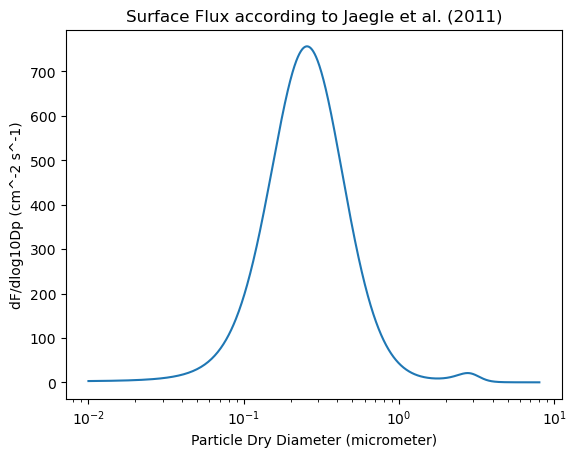

In [2]:
## use coefficients by Jaegle et al. (2011) to generate a small data base of surface flux size distribution
SST = 5
vh = 20
STEP = 0.001

JAEGLE_DAT = pd.DataFrame()
## loop over a range of diameters
for DD in np.arange(0.01,8.,STEP): 
    A = 4.7*(1 + 30 * (DD/2))**(-0.017*(DD/2)**(-1.44))
    B =(0.433 - np.log(DD/2))/0.433
    SST_TERM = (0.3 + 0.1*SST - 0.0076*SST**2.0 + 0.00021*SST**3.0)
    
    ## number flux
    FN = SST_TERM*1.373*vh**3.41*(DD/2)**(-A)*(1+0.057*(DD/2)**3.45)*10**(1.607*np.exp(-B**2.0)) / 100 /100
    
    ## associated area flux
    SA = FN*np.pi*(DD**2)
    
    ## store in data frame
    TMP = pd.DataFrame([[DD,FN,SA,vh,SST]],columns=['Dp','FN','SA','vh','SST'])
    JAEGLE_DAT = pd.concat([JAEGLE_DAT,TMP])


plt.plot(JAEGLE_DAT['Dp'],JAEGLE_DAT['FN'])
plt.xscale("log",base=10)
plt.xlabel('Particle Dry Diameter (micrometer)')
plt.ylabel('dF/dlog10Dp (cm^-2 s^-1)')
plt.title('Surface Flux according to Jaegle et al. (2011)')

Text(0.5, 1.0, 'Partitioning of Surface Flux')

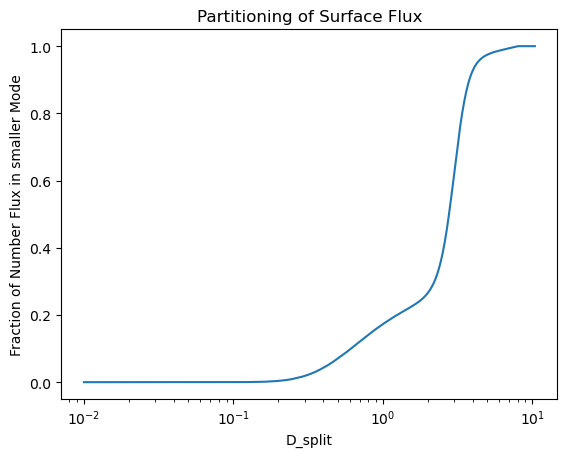

In [3]:
## partition into two groups and integrate over size
def split_flux(DAT,D_s,STEP,mode='number'):
    if mode=='number':
        #num_1 = np.sum(DAT.loc[DAT['Dp'] <  D_s - STEP/2]['FN'] * np.log10((DAT.loc[DAT['Dp'] <  D_s - STEP/2]['Dp']+STEP) / DAT.loc[DAT['Dp'] <  D_s- STEP/2]['Dp']))
        #num_2 = np.sum(DAT.loc[DAT['Dp'] >= D_s - STEP/2]['FN'] * np.log10((DAT.loc[DAT['Dp'] >= D_s - STEP/2]['Dp']+STEP) / DAT.loc[DAT['Dp'] >= D_s - STEP/2]['Dp']))
        num_1 = np.sum(DAT.loc[DAT['Dp'] <  D_s - STEP/2]['FN'] * STEP)
        num_2 = np.sum(DAT.loc[DAT['Dp'] >= D_s - STEP/2]['FN'] * STEP)
    else:
        num_1 = np.sum(DAT.loc[DAT['Dp'] <  D_s - STEP/2]['SA'] * STEP)
        num_2 = np.sum(DAT.loc[DAT['Dp'] >= D_s - STEP/2]['SA'] * STEP)
        
    return [num_1/(num_1 + num_2),num_2/(num_1 + num_2)]

PARTITION_DAT = pd.DataFrame()
## loop over a range of diameters
for DD_split in np.arange(np.log(0.01),np.log(10.5),0.01): 
    TMP   = split_flux(JAEGLE_DAT,D_s = np.exp(DD_split),STEP=STEP,mode='number')
    TMP_2 = split_flux(JAEGLE_DAT,D_s = np.exp(DD_split),STEP=STEP,mode='area')
    TMP_DAT = pd.DataFrame([[TMP[0],TMP[1],TMP_2[0],TMP_2[1],np.exp(DD_split)]],columns=['frac_1','frac_2','frac_area_1','frac_area_2','D_split'])
    PARTITION_DAT = pd.concat([PARTITION_DAT,TMP_DAT])
    
plt.plot(PARTITION_DAT['D_split'],PARTITION_DAT['frac_area_1'])
plt.xscale("log")
plt.xlabel('D_split')
plt.ylabel('Fraction of Number Flux in smaller Mode')
plt.title('Partitioning of Surface Flux')

In [4]:
import math

## utilize modes as specified by aerosol team (i.e., A. Williams and L. Russell)
PSD_zsm = pd.read_excel('https://docs.google.com/spreadsheets/d/' +
                        '1q4YkJc5dF-ZOIx-xWU_IkmTYCUPoM0kODj5ro_7Vg_c' +
                        '/export?gid=0&format=xlsx',
                        sheet_name='PSD')

PSD_zsm

,Mode,N_a,D_g,sigma_g,kappa
0,Aitken,58,0.04,1.7,0.3
1,Accumulation,134,0.14,1.6,0.5
2,Sea Spray,2,0.50,1.7,0.9


In [5]:
## determine where normalized middle and large mode intercept in density

INTERCEPT_DAT = pd.DataFrame()
for DD in np.arange(0.01,8.,STEP): 
    d_1 = DD*1000
    d_2 = 10000
    
    num_frac_1 = 0.5*(1 + math.erf((np.log(d_1) - np.log(PSD_zsm['D_g'][1]*1000)) / (np.log(PSD_zsm['sigma_g'][1])* np.sqrt(2))))
    num_frac_2 = 0.5*(1 + math.erf((np.log(d_1) - np.log(PSD_zsm['D_g'][2]*1000)) / (np.log(PSD_zsm['sigma_g'][2])* np.sqrt(2))))

    exp_sd_2 = np.exp(2*np.log(PSD_zsm['sigma_g'][1])**2)
    dum_1 = np.log(d_1/(PSD_zsm['D_g'][1]*1000*exp_sd_2))/(np.sqrt(2)*np.log(PSD_zsm['sigma_g'][1]))
    dum_2 = np.log(d_2/(PSD_zsm['D_g'][1]*1000*exp_sd_2))/(np.sqrt(2)*np.log(PSD_zsm['sigma_g'][1]))    
    area_frac_1 = 0.5*(math.erf(dum_2) - math.erf(dum_1))
    
    exp_sd_2 = np.exp(2*np.log(PSD_zsm['sigma_g'][2])**2)
    dum_1 = np.log(d_1/(PSD_zsm['D_g'][2]*1000*exp_sd_2))/(np.sqrt(2)*np.log(PSD_zsm['sigma_g'][2]))
    dum_2 = np.log(d_2/(PSD_zsm['D_g'][2]*1000*exp_sd_2))/(np.sqrt(2)*np.log(PSD_zsm['sigma_g'][2]))    
    area_frac_2 = 0.5*(math.erf(dum_2) - math.erf(dum_1))
    
    ## store in data frame
    TMP = pd.DataFrame([[DD,num_frac_1,num_frac_2,area_frac_1,area_frac_2]],columns=['Dp','num_frac_1','num_frac_2','area_frac_1','area_frac_2'])
    INTERCEPT_DAT = pd.concat([INTERCEPT_DAT,TMP])

In [6]:
INTERCEPT_DAT['num_frac_diff'] = np.abs(INTERCEPT_DAT['num_frac_1'] - (1 - INTERCEPT_DAT['num_frac_2']))
D_split = INTERCEPT_DAT['Dp'][INTERCEPT_DAT['num_frac_diff'] == INTERCEPT_DAT['num_frac_diff'].min()][0]
print('Normalized middle and large mode intercept at ' + str(np.round(D_split*1000)) + ' nm')

Normalized middle and large mode intercept at 255.0 nm


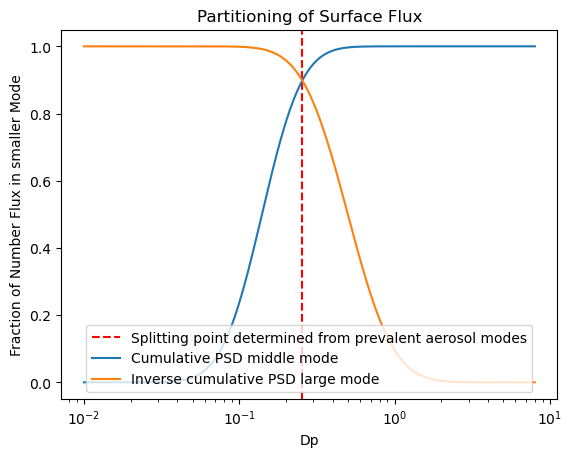

In [7]:
plt.axvline(x = D_split, color = 'r', ls='dashed',label = 'Splitting point determined from prevalent aerosol modes')
plt.plot(INTERCEPT_DAT['Dp'],INTERCEPT_DAT['num_frac_1'],label='Cumulative PSD middle mode')
plt.plot(INTERCEPT_DAT['Dp'],1-INTERCEPT_DAT['num_frac_2'],label='Inverse cumulative PSD large mode')
plt.xscale("log")
plt.xlabel('Dp')
plt.ylabel('Fraction of Number Flux in smaller Mode')
plt.title('Partitioning of Surface Flux')
plt.legend(loc=8)

In [8]:
## apply simple determination of splitting point based on middle mode
print('Splitting modes at ' + str(np.round(D_split,3)) + ' um')

## look up proportion of flux 
PARTITION_DAT['Dp_dist'] = np.abs(PARTITION_DAT['D_split'] - D_split)
PARTITION_DAT.loc[PARTITION_DAT['Dp_dist']==PARTITION_DAT['Dp_dist'].min()]

print('Number-equivalent flux: middle mode receives '+
      str(np.round(PARTITION_DAT.loc[PARTITION_DAT['Dp_dist']==PARTITION_DAT['Dp_dist'].min()]['frac_1'][0],3))+
      ' and large receives '+
      str(np.round(PARTITION_DAT.loc[PARTITION_DAT['Dp_dist']==PARTITION_DAT['Dp_dist'].min()]['frac_2'][0],3)))

print('Area-equivalent flux: middle mode receives '+
      str(np.round(PARTITION_DAT.loc[PARTITION_DAT['Dp_dist']==PARTITION_DAT['Dp_dist'].min()]['frac_area_1'][0],3))+
      ' and large receives '+
      str(np.round(PARTITION_DAT.loc[PARTITION_DAT['Dp_dist']==PARTITION_DAT['Dp_dist'].min()]['frac_area_2'][0],3)))

Splitting modes at 0.255 um
Number-equivalent flux: middle mode receives 0.265 and large receives 0.735
Area-equivalent flux: middle mode receives 0.01 and large receives 0.99


Text(0.5, 1.0, 'Area')

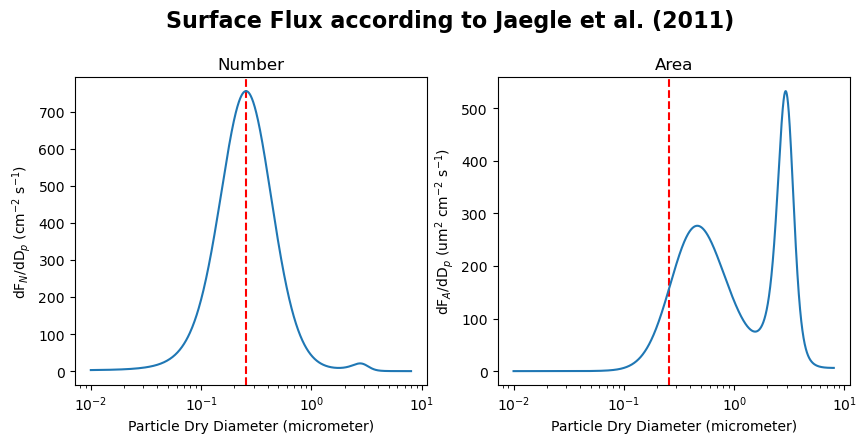

In [11]:
#plt.plot(PARTITION_DAT['D_split'],PARTITION_DAT['num_1'])
#plt.axvline(x = D_split, color = 'r', ls='dashed',label = 'Splitting point determined from prevalent aerosol modes')
#plt.xscale("log")
#plt.xlabel('D_split')
#plt.ylabel('Fraction of Number Flux in smaller Mode')
#plt.title('Partitioning of Surface Flux')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Surface Flux according to Jaegle et al. (2011)', fontsize=16, fontweight='bold', y=1.05)

ax1.set_xscale('log')
ax1.axvline(x = D_split, color = 'r', ls='dashed',label = 'Splitting point determined from prevalent aerosol modes')
ax1.plot(JAEGLE_DAT['Dp'],JAEGLE_DAT['FN'])
ax1.set_xlabel('Particle Dry Diameter (micrometer)')
ax1.set_ylabel('dF$_N$/dD$_p$ (cm$^{-2}$ s$^{-1}$)')
ax1.set_title('Number')

ax2.set_xscale('log')
ax2.axvline(x = D_split, color = 'r', ls='dashed',label = 'Splitting point determined from prevalent aerosol modes')
ax2.plot(JAEGLE_DAT['Dp'],JAEGLE_DAT['SA'])
ax2.set_xlabel('Particle Dry Diameter (micrometer)')
ax2.set_ylabel('dF$_A$/dD$_p$ (um$^2$ cm$^{-2}$ s$^{-1}$)')
ax2.set_title('Area')

Text(0.5, 1.0, 'Number')

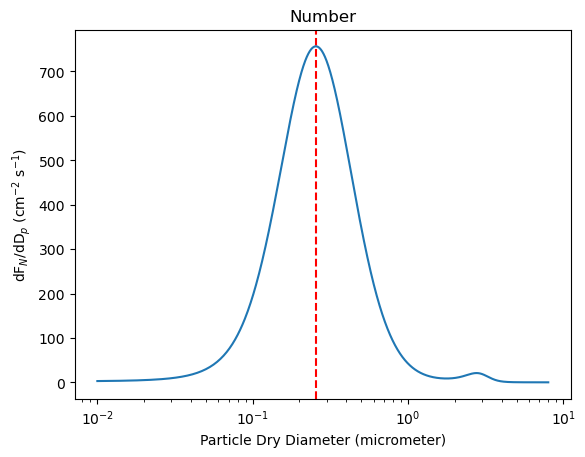

In [12]:

plt.xscale('log')
plt.axvline(x = D_split, color = 'r', ls='dashed',label = 'Splitting point determined from prevalent aerosol modes')
plt.plot(JAEGLE_DAT['Dp'],JAEGLE_DAT['FN'])
plt.xlabel('Particle Dry Diameter (micrometer)')
#plt.ylabel('dF$_N$/dlog$_{10}$D$_p$ (cm$^{-2}$ s$^{-1}$)')
plt.ylabel('dF$_N$/dD$_p$ (cm$^{-2}$ s$^{-1}$)')
plt.title('Number')


# Jaegle et al. (2011) surface particle flux integrated over all sizes
* $\text{SST}$ is sea surface skin temperature in °C
* $v_h$ is horizontal wind speed at 10 m
* $F_N$ in particle number per square centimeter and second
* For example, fluxed into the lowest atmospheric layer: $S_{srf} = \frac{F_N 10^4}{\rho \Delta z}$

$$
  F_N = 0.019793 ~ v_h^{3.41} (0.3 + 0.1 ~ \text{SST} - 0.0076 ~ \text{SST}^2 + 0.00021 ~ \text{SST}^3)
$$

<div class="alert alert-block alert-info">
<b>For MIP:</b>  Please compute interactive sea-spray fluxes using prevalent SST and 10 meter windspeed.
</div>

<div class="alert alert-block alert-warning">
<b>Update for MIP:</b>  For supercooled SST, please compute interactive sea-spray fluxes using SST = 0 °C to allow aerosol surface fluxes at all SST.
</div>

<div class="alert alert-block alert-success">
<b>Success:</b> Please note the updated surface flux fractions for middle and large aerosol modes that ensure sufficient surface area for prognostic Ni: 26.5% (middle) and 73.5% (large).
</div>